# MNIST 次元削減の復元精度・プライバシー攻撃 実験

このノートブックでは、`dimensionality_reduction.py` と `anchor_utils.py` を用いて、
次元削減後の表現から元の特徴量をどの程度復元できるか、および将来的なプライバシー攻撃の実験用の枠組みを用意します。

基本設定は `base_config` で与えられた MNIST 用の設定を使用します。


# 局所流出

In [13]:
# ノートブックの最初でリポジトリ直下に移動
import os
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "input").exists():
    for p in repo_root.parents:
        if (p / "input").exists():
            repo_root = p
            break

os.chdir(repo_root)
print("CWD:", os.getcwd())


CWD: /Users/suetake/git-repos/takano_labo/dca


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def show_original_vs_recon(X_true, X_recon, n=10, y=None, labels=None):
    """
    X_true, X_recon: (N, 784)
    y:              (N,)  元のラベル（任意）
    labels:         ラベルのリストを指定したら、その順で最大5個だけ可視化
    """
    if labels is not None and y is not None:
        # ラベル順に最大5個だけ
        labels = list(labels)[:5]
        fig, axes = plt.subplots(2, len(labels), figsize=(1.5*len(labels), 3))
        for i, lab in enumerate(labels):
            idx_candidates = np.where(y == lab)[0]
            if len(idx_candidates) == 0:
                # そのラベルが無ければ空白
                axes[0, i].axis("off")
                axes[1, i].axis("off")
                axes[0, i].set_title(f"{lab}(none)")
                continue
            k = idx_candidates[0]

            orig = X_true[k].reshape(28, 28)
            recon = X_recon[k].reshape(28, 28)

            axes[0, i].imshow(orig, cmap="gray")
            axes[0, i].axis("off")
            axes[0, i].set_title(f"orig {lab}")

            axes[1, i].imshow(recon, cmap="gray")
            axes[1, i].axis("off")
            axes[1, i].set_title("recon")
        plt.tight_layout()
        plt.show()
        return

    # それ以外（labels 指定なし）の場合はランダムに n 個
    idx = np.random.choice(len(X_true), size=n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i, k in enumerate(idx):
        orig = X_true[k].reshape(28, 28)
        recon = X_recon[k].reshape(28, 28)

        axes[0, i].imshow(orig, cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("orig")

        axes[1, i].imshow(recon, cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("recon")

    plt.tight_layout()
    plt.show()



In [15]:
import numpy as np
import pandas as pd
from types import SimpleNamespace
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, pairwise_distances
import random
from config.config import Config
from src.institution_data_pipeline.load_data import load_data
from src.intermediate_expression import anchor_utils
from src import dimensionality_reduction

from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error, accuracy_score


def run_anchor_local_leak_reconstruction(base_config) -> dict:
    """
    ・アンカーは「ラベル a（最小ラベル）の近傍」にあるものから spill_num 個だけ漏洩
    ・疑似逆行列 / MLP で f^-1 を近似
    ・RMSE を
        - ラベル a のみ
        - ラベル a 以外
        - 全体
      について計算して print し、dict で返す
    """
    # ---- config を Config に整形 ----
    if isinstance(base_config, Config):
        cfg = base_config
    elif isinstance(base_config, dict):
        cfg = Config(**base_config)
    else:  # SimpleNamespace 等
        cfg = Config(**vars(base_config))
        
    # ここで全乱数の seed を固定
    seed = int(cfg.seed)
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    random.seed(seed)

    # ---- 前処理込みで DataFrame を取得 ----
    df_full = load_data(cfg)  # one-hot + 標準化済み

    n_total = len(df_full)
    n_use = min(n_total, int(cfg.num_institution_user))
    idx = rng.choice(n_total, size=n_use, replace=False)
    df_sub = df_full.iloc[idx].reset_index(drop=True)

    y = df_sub[cfg.y_name].to_numpy()
    X = df_sub.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)
    
    idx = rng.permutation(100)
    X_public = X[idx]
    y_public = y[idx]

    # public に使った部分を除いた残り
    mask = np.ones(len(y), dtype=bool)
    mask[idx] = False
    X = X[mask]
    y = y[mask]


    # ラベル a = 最小ラベル
    labels = np.unique(y)
    a_label = labels[0]
    mask_a = (y == a_label)
    mask_not_a = ~mask_a

    # ---- 次元削減器の構築 ----
    projector = dimensionality_reduction.build_dimensionality_projector(
        X,
        n_components=int(cfg.dim_intermediate),
        F_type=cfg.F_type,
        seed=int(cfg.seed),
        config=cfg,
        y=y,
    )
    X_tilde = projector(X)

    # ---- アンカー生成 ----
    num_row = int(cfg.num_anchor_data)
    num_col = X.shape[1]

    anchor_cfg = SimpleNamespace(
        anchor_method=cfg.anchor_method,
        y_name=cfg.y_name,
        smote_ratio=1.0,
    )

    A = anchor_utils.produce_anchor(
        num_row=num_row,
        num_col=num_col,
        seed=int(cfg.seed),
        config=anchor_cfg,
        train_df=df_sub,
        Xs_train=[X],
        Xs_test=[X],
        ys_train=[y],
        ys_test=[y],
        smote_X=X_public, 
        smote_y=y_public,
    )

    A_tilde = projector(A)

    if cfg.spill_type == "random":   
        # ---- アンカー leak 部分の抽出 ----
        spill_num = min(int(cfg.spill_num), A.shape[0])
        idx_leak = rng.choice(A.shape[0], size=spill_num, replace=False)
        A_leak = A[idx_leak]
        A_tilde_leak = A_tilde[idx_leak]
        
    if cfg.spill_type == "local":
        # ---- アンカー leak 部分の抽出（ラベル a 近傍から）----
        spill_num = min(int(cfg.spill_num), A.shape[0])

        Xa = X[mask_a]
        # A と Xa の距離行列 → 各アンカーとラベル a データの最短距離
        dist_mat = pairwise_distances(A, Xa, metric="euclidean")
        min_dists_to_a = dist_mat.min(axis=1)

        # ラベル a に近い順に spill_num 個だけ流出
        idx_sorted = np.argsort(min_dists_to_a)
        idx_leak = idx_sorted[:spill_num]

        A_leak = A[idx_leak]
        A_tilde_leak = A_tilde[idx_leak]
        
    if cfg.spill_type == "even":    
        # ランダム
        # ---- アンカー leak 部分の抽出 ----
        spill_num = min(int(cfg.spill_num), A.shape[0])

        # ---- アンカーごとのラベルを「一番近い訓練サンプルのラベル」で付ける ----
        # 距離行列: 各アンカー vs 全訓練サンプル
        D_anchor_train = pairwise_distances(A, X, metric="euclidean")
        nearest_idx = np.argmin(D_anchor_train, axis=1)    # (num_anchor,)
        anchor_labels = y[nearest_idx]                     # 各アンカーの近傍ラベル

        labels = np.unique(y)
        L = len(labels)

        # ラベルごとに spill_num を均等に割り当て（端数は後で調整）
        base_per_label = spill_num // L

        idx_leak_list = []

        for c in labels:
            anchor_idx_c = np.where(anchor_labels == c)[0]
            if len(anchor_idx_c) == 0:
                continue
            n_pick = min(base_per_label, len(anchor_idx_c))
            if n_pick > 0:
                idx_leak_list.append(
                    rng.choice(anchor_idx_c, size=n_pick, replace=False)
                )

        # ここまででまだ足りない分（端数）を、残りのアンカーからランダムに補充
        chosen = np.concatenate(idx_leak_list) if idx_leak_list else np.array([], dtype=int)
        remaining_needed = spill_num - len(chosen)
        if remaining_needed > 0:
            all_idx = np.arange(A.shape[0])
            remaining_pool = np.setdiff1d(all_idx, chosen)
            extra = rng.choice(
                remaining_pool,
                size=min(remaining_needed, len(remaining_pool)),
                replace=False,
            )
            idx_leak_list.append(extra)

        idx_leak = np.concatenate(idx_leak_list)

        A_leak = A[idx_leak]
        A_tilde_leak = A_tilde[idx_leak]

    # ---- 疑似逆行列ベースの f^{-1} 学習 ----
    Z = A_tilde_leak          # (spill_num, k)
    X_target = A_leak         # (spill_num, d)

    # Z @ W ≈ X_target
    W_pinv, *_ = np.linalg.lstsq(Z, X_target, rcond=None)

    def f_inv_pinv(Z_input: np.ndarray) -> np.ndarray:
        return Z_input @ W_pinv

    X_rec_pinv = f_inv_pinv(X_tilde)

    Z = A_tilde_leak          # (spill_num, k)
    X_target = A_leak         # (spill_num, d)

    # # ---- L2 正則化付き（ridge）逆写像 ----
    lam = 1e-3  # 正則化係数は好みで調整

    ZTZ = Z.T @ Z                          # (k, k)
    k = ZTZ.shape[0]
    W_ridge = np.linalg.solve(
        ZTZ + lam * np.eye(k),            # (k, k)
        Z.T @ X_target                    # (k, d)
    )

    def f_inv_pinv(Z_input: np.ndarray) -> np.ndarray:
        return Z_input @ W_ridge

    X_rec_pinv = f_inv_pinv(X_tilde)
    
    # ---- ラベル a / not_a の復元画像を可視化 ----
    if cfg.dataset in ("mnist", "fashion_mnist"):
        # ラベル a
        X_a = X[mask_a]
        X_rec_pinv_a = X_rec_pinv[mask_a]
        if len(X_a) >= 5:
            print(f"Label a = {a_label} の例 (pseudo-inverse recon)")
            show_original_vs_recon(X_a, X_rec_pinv_a, n=5)
        # ラベル not_a
        X_not_a = X[mask_not_a]
        y_not_a = y[mask_not_a]
        X_rec_pinv_not_a = X_rec_pinv[mask_not_a]
        if len(X_not_a) >= 5:
            print("Label not-a の例 (pseudo-inverse recon)")
            show_original_vs_recon(X_not_a, X_rec_pinv_not_a, n=5, y=y_not_a, labels=[1, 2, 3, 4, 5])


    # ---- MLP による f^{-1} 近似 ----
    scaler_z = StandardScaler()
    Z_train = scaler_z.fit_transform(A_tilde_leak)

    mlp = MLPRegressor(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        random_state=int(cfg.seed),
    )
    mlp.fit(Z_train, A_leak)

    Z_all = scaler_z.transform(X_tilde)
    X_rec_mlp = mlp.predict(Z_all)

    # ---- ラベル別 RMSE 計算 ----
    def _rmse(X_true, X_hat, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            X_true = X_true[mask]
            X_hat = X_hat[mask]
        return float(np.sqrt(mean_squared_error(X_true, X_hat)))

    # pseudo-inverse
    rmse_pinv_all = _rmse(X, X_rec_pinv)
    rmse_pinv_a = _rmse(X, X_rec_pinv, mask_a)
    rmse_pinv_not_a = _rmse(X, X_rec_pinv, mask_not_a)

    # MLP
    rmse_mlp_all = _rmse(X, X_rec_mlp)
    rmse_mlp_a = _rmse(X, X_rec_mlp, mask_a)
    rmse_mlp_not_a = _rmse(X, X_rec_mlp, mask_not_a)

    # ---- 分類器でラベル予測精度を評価 ----
    clf = MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=int(cfg.seed),
    )
    clf.fit(X, y)  # 元の X で学習

    # 予測
    y_pred_pinv = clf.predict(X_rec_pinv)
    y_pred_mlp = clf.predict(X_rec_mlp)

    def _acc(y_true, y_pred, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            y_true = y_true[mask]
            y_pred = y_pred[mask]
        return float(accuracy_score(y_true, y_pred))

    # pseudo-inverse
    acc_pinv_all = _acc(y, y_pred_pinv)
    acc_pinv_a = _acc(y, y_pred_pinv, mask_a)
    acc_pinv_not_a = _acc(y, y_pred_pinv, mask_not_a)

    # MLP
    acc_mlp_all = _acc(y, y_pred_mlp)
    acc_mlp_a = _acc(y, y_pred_mlp, mask_a)
    acc_mlp_not_a = _acc(y, y_pred_mlp, mask_not_a)


    # ---- 結果の表示と返却 ----
    print(
        f"[anchor_local_leak] dataset={cfg.dataset}, F_type={cfg.F_type}, "
        f"dim={X_tilde.shape[1]}, spill_num={spill_num}, a_label={a_label}"
    )
    # print("  pseudo-inverse RMSE  : "
    #       f"all={rmse_pinv_all:.6f}, a={rmse_pinv_a:.6f}, not-a={rmse_pinv_not_a:.6f}")
    # print("  MLP recon RMSE       : "
    #       f"all={rmse_mlp_all:.6f}, a={rmse_mlp_a:.6f}, not-a={rmse_mlp_not_a:.6f}")

    print("  pseudo-inverse ACC   : "
          f"all={acc_pinv_all:.4f}, a={acc_pinv_a:.4f}, not-a={acc_pinv_not_a:.4f}")
    print("  MLP recon ACC        : "
          f"all={acc_mlp_all:.4f}, a={acc_mlp_a:.4f}, not-a={acc_mlp_not_a:.4f}")

    return {
        "a_label": a_label,
        "rmse_pinv_all": rmse_pinv_all,
        "rmse_pinv_a": rmse_pinv_a,
        "rmse_pinv_not_a": rmse_pinv_not_a,
        "rmse_mlp_all": rmse_mlp_all,
        "rmse_mlp_a": rmse_mlp_a,
        "rmse_mlp_not_a": rmse_mlp_not_a,
        "acc_pinv_all": acc_pinv_all,
        "acc_pinv_a": acc_pinv_a,
        "acc_pinv_not_a": acc_pinv_not_a,
        "acc_mlp_all": acc_mlp_all,
        "acc_mlp_a": acc_mlp_a,
        "acc_mlp_not_a": acc_mlp_not_a,
        #"W_pinv": W_pinv,
        #"mlp": mlp,
        #"clf": clf,
        "X": X,
        "y": y,
        "X_tilde": X_tilde,
        "A_leak": A_leak,
        "A_tilde_leak": A_tilde_leak,
        "idx_leak": idx_leak,
    }


In [16]:
from config.config import Config

base_config_dict = {
    "name": "tutorial_mnist",
    "dataset": "mnist",
    "y_name": "target",
    "num_institution_user": 1200,
    "data_distribution": "even",
    "anchor_method": "smote",
    "num_anchor_data": 500,
    "dim_intermediate": 600,
    "F_type": "svd",
    "seed": 42,
    "inter_normalization": False,
    "spill_num": 100,
    "preprocess":False,
}

base_config = Config(**base_config_dict)


In [17]:

from itertools import product
import pandas as pd
from config.config import Config

def run_anchor_local_leak_grid(base_config_dict: dict):
    """
    base_config_dict の各キーにリストを入れておくと、
    その直積（全組み合わせ）で Config を作り、
    run_anchor_local_leak_reconstruction(Config) を全パターン実行する。
    戻り値: 結果をまとめた DataFrame
    """
    keys = list(base_config_dict.keys())
    value_lists = [
        (v if isinstance(v, (list, tuple)) else [v])
        for v in (base_config_dict[k] for k in keys)
    ]

    records = []

    for values in product(*value_lists):
        cfg_kwargs = {k: v for k, v in zip(keys, values)}
        cfg = Config(**cfg_kwargs)

        res = run_anchor_local_leak_reconstruction(cfg)  # さっき作った関数

        record = dict(cfg_kwargs)
        # record["rmse_pinv"] = res["rmse_pinv_all"]
        # record["rmse_pinv_a"] = res["rmse_pinv_a"]
        # record["rmse_pinv_not_a"] = res["rmse_pinv_not_a"]
        # record["rmse_mlp"] = res["rmse_mlp_all"]
        # record["rmse_mlp_a"] = res["rmse_mlp_a"]
        # record["rmse_mlp_not_a"] = res["rmse_mlp_not_a"]
        
        # ここから accuracy
        record["acc_pinv"] = res["acc_pinv_all"]
        #record["acc_pinv_a"] = res["acc_pinv_a"]
        #record["acc_pinv_not_a"] = res["acc_pinv_not_a"]
        record["acc_mlp"] = res["acc_mlp_all"]
        #record["acc_mlp_a"] = res["acc_mlp_a"]
        #record["acc_mlp_not_a"] = res["acc_mlp_not_a"]
        record["acc_proc"] = res["acc_proc_all"]
        #record["acc_proc_a"] = res["acc_proc_a"]
        #record["acc_proc_not_a"] = res["acc_proc_not_a"]
        record["acc_pinv_orth"] = res["acc_pinv_orth_all"]
        records.append(record)

    return pd.DataFrame(records)

In [18]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["even"], # "local", "even", 
    "y_name": ["target"],
    "num_institution_user": [1000],
    "data_distribution": ["even"],
    "anchor_method": ["smote"], # "smote"
    "num_anchor_data": [1000],
    "dim_intermediate": [700],
    "spill_num": [1000],
    "F_type": ["svd","umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [True],
    "preprocess":[False],
    "smote_ratio": [0.8],
    "gamma_ratio": [1.0],
    "seed":[3]
}
# df_results = run_anchor_local_leak_grid(base_config_dict)
# df_results

In [19]:
from sklearn.metrics import pairwise_distances

def select_leak_random(A, A_tilde, spill_num, rng):
    spill_num = min(spill_num, A.shape[0])
    idx_leak = rng.choice(A.shape[0], size=spill_num, replace=False)
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak_local(A, A_tilde, X, y, a_label, spill_num):
    spill_num = min(spill_num, A.shape[0])
    Xa = X[y == a_label]
    dist_mat = pairwise_distances(A, Xa, metric="euclidean")
    min_dists_to_a = dist_mat.min(axis=1)
    idx_sorted = np.argsort(min_dists_to_a)
    idx_leak = idx_sorted[:spill_num]
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak_even(A, A_tilde, X, y, spill_num, rng):
    spill_num = min(spill_num, A.shape[0])

    # 近傍訓練データのラベルでアンカーにラベル付け
    D_anchor_train = pairwise_distances(A, X, metric="euclidean")
    nearest_idx = np.argmin(D_anchor_train, axis=1)
    anchor_labels = y[nearest_idx]

    labels = np.unique(y)
    L = len(labels)
    base_per_label = spill_num // L

    idx_leak_list = []
    for c in labels:
        anchor_idx_c = np.where(anchor_labels == c)[0]
        if len(anchor_idx_c) == 0:
            continue
        n_pick = min(base_per_label, len(anchor_idx_c))
        if n_pick > 0:
            idx_leak_list.append(rng.choice(anchor_idx_c, size=n_pick, replace=False))

    chosen = np.concatenate(idx_leak_list) if idx_leak_list else np.array([], dtype=int)
    remaining_needed = spill_num - len(chosen)
    if remaining_needed > 0:
        all_idx = np.arange(A.shape[0])
        remaining_pool = np.setdiff1d(all_idx, chosen)
        extra = rng.choice(
            remaining_pool,
            size=min(remaining_needed, len(remaining_pool)),
            replace=False,
        )
        idx_leak_list.append(extra)

    idx_leak = np.concatenate(idx_leak_list) if idx_leak_list else np.array([], dtype=int)
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak(A, A_tilde, X, y, a_label, cfg, rng):
    """cfg.spill_type に応じて leak アンカーを選ぶ統一インターフェース。"""
    spill_num = int(cfg.spill_num)
    if cfg.spill_type == "random":
        return select_leak_random(A, A_tilde, spill_num, rng)
    elif cfg.spill_type == "local":
        return select_leak_local(A, A_tilde, X, y, a_label, spill_num)
    elif cfg.spill_type == "even":
        return select_leak_even(A, A_tilde, X, y, spill_num, rng)
    else:
        # デフォルトは random
        return select_leak_random(A, A_tilde, spill_num, rng)


In [20]:

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


def reconstruct_linear_pinv_centered(A_tilde_leak, A_leak, X_tilde):
    Z = np.asarray(A_tilde_leak, float)
    X = np.asarray(A_leak, float)

    Z_mean = Z.mean(axis=0, keepdims=True)
    X_mean = X.mean(axis=0, keepdims=True)
    Zc = Z - Z_mean
    Xc = X - X_mean

    W_c, *_ = np.linalg.lstsq(Zc, Xc, rcond=None)
    X_rec = (X_tilde - Z_mean) @ W_c + X_mean
    return X_rec, W_c, Z_mean, X_mean


def reconstruct_linear_ridge(A_tilde_leak, A_leak, X_tilde, lam=1e-3):
    """Z @ W ≈ X_target を ridge で学習し、X_tilde から復元する（中心化付き）。"""
    Z = np.asarray(A_tilde_leak, float)  # (n_leak, k)
    X = np.asarray(A_leak, float)        # (n_leak, d)

    # 1. リークアンカーの統計だけで中心化
    Z_mean = Z.mean(axis=0, keepdims=True)   # (1, k)
    X_mean = X.mean(axis=0, keepdims=True)   # (1, d)
    Zc = Z - Z_mean
    Xc = X - X_mean

    # 2. 中心化後の ridge 解
    ZTZ = Zc.T @ Zc
    k = ZTZ.shape[0]
    W = np.linalg.solve(
        ZTZ + lam * np.eye(k),
        Zc.T @ Xc,
    )  # (k, d)

    # 3. 任意の X_tilde を復元（同じ中心でシフト）
    X_rec = (X_tilde - Z_mean) @ W + X_mean
    return X_rec, W


def reconstruct_mlp(A_tilde_leak, A_leak, X_tilde, cfg):
    Z = np.asarray(A_tilde_leak, float)
    X = np.asarray(A_leak, float)

    # 入力側: 平均0（＋スケーリング）は従来通り
    scaler_z = StandardScaler()
    Z_train = scaler_z.fit_transform(Z)

    # 出力側: 平均を引いて学習し、あとで戻す
    X_mean = X.mean(axis=0, keepdims=True)
    Xc = X - X_mean

    mlp = MLPRegressor(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        random_state=int(cfg.seed),
    )
    mlp.fit(Z_train, Xc)

    Z_all = scaler_z.transform(X_tilde)
    X_rec_c = mlp.predict(Z_all)
    X_rec_mlp = X_rec_c + X_mean
    return X_rec_mlp, mlp


def reconstruct_procrustes_pinv_style(A_tilde_leak, A_leak, X_tilde):
    """
    pinv と同じペア (Z, X_target) = (A_tilde_leak, A_leak) を使い、
    Z -> X の写像を「直交＋平行移動」制約付きで学習する。
    """
    Z = np.asarray(A_tilde_leak, float)   # (n_leak, k)
    X = np.asarray(A_leak, float)         # (n_leak, d)

    # 1. 両方をサンプル平均で中心化
    Z_mean = Z.mean(axis=0, keepdims=True)    # (1, k)
    X_mean = X.mean(axis=0, keepdims=True)    # (1, d)
    Zc = Z - Z_mean
    Xc = X - X_mean

    # 2. 直交 Procrustes: min_W ||Zc W - Xc||_F,  W^T W = I
    #    近似解: M = Zc^T Xc に対し SVD -> W_ortho = U V^T
    M = Zc.T @ Xc                         # (k, d)
    U, _, Vt = np.linalg.svd(M, full_matrices=False)
    W_ortho = U @ Vt                      # (k, d), 列がほぼ直交

    # 3. 任意の X_tilde に対する復元
    #    Z ≈ (X_tilde - Z_mean) とみなして
    X_rec = (X_tilde - Z_mean) @ W_ortho + X_mean
    return X_rec, W_ortho, Z_mean, X_mean

def reconstruct_pinv_orth(A_tilde_leak, A_leak, X_tilde):
    """
    A_tilde ≈ (A - mu) F を仮定し、
    (A_leak, A_tilde_leak) から F と mu を最小二乗で推定。
    復元は F の擬似逆 ≈ F^T を用いて x̂ = X_tilde F^T + mu で行う。
    （直交射影は行わない）
    """
    A = np.asarray(A_leak, float)         # (n_leak, d)
    Z = np.asarray(A_tilde_leak, float)   # (n_leak, k)

    # 1. 平均で中心化
    mean_A = A.mean(axis=0, keepdims=True)   # (1, d)
    mean_Z = Z.mean(axis=0, keepdims=True)   # (1, k)
    A_c = A - mean_A
    Z_c = Z - mean_Z

    # 2. A_c F ≈ Z_c を最小二乗で解いて F_hat を推定（d -> k）
    #    A_c: (n, d), Z_c: (n, k) => F_hat: (d, k)
    F_hat, *_ = np.linalg.lstsq(A_c, Z_c, rcond=None)

    # 3. 平行移動 mu を推定:
    #    Z ≈ (A - mu) F_hat なので mean_Z ≈ (mean_A - mu) F_hat
    #    => mu ≈ mean_A - mean_Z F_hat^T
    mu_hat = (mean_A - mean_Z @ F_hat.T).ravel()   # (d,)

    # 4. 任意の X_tilde を復元: x̂ = X_tilde F_hat^T + mu_hat
    X_rec = X_tilde @ F_hat.T + mu_hat
    return X_rec, F_hat, mu_hat

def reconstruct_pinv_not_orth(A_tilde_leak, A_leak, X_tilde):
    """
    A_tilde ≈ (A - mu) F を仮定し、
    (A_leak, A_tilde_leak) から F と mu を最小二乗で推定。
    直交性は仮定せず、F の擬似逆 F^+ を用いて
    x̂ = X_tilde F^+ + mu で復元する。
    """
    A = np.asarray(A_leak, float)         # (n_leak, d)
    Z = np.asarray(A_tilde_leak, float)   # (n_leak, k)

    # 1. 平均で中心化
    mean_A = A.mean(axis=0, keepdims=True)   # (1, d)
    mean_Z = Z.mean(axis=0, keepdims=True)   # (1, k)
    A_c = A - mean_A
    Z_c = Z - mean_Z

    # 2. A_c F ≈ Z_c を最小二乗で解いて F_hat を推定（d -> k）
    #    A_c: (n, d), Z_c: (n, k) => F_hat: (d, k)
    F_hat, *_ = np.linalg.lstsq(A_c, Z_c, rcond=None)

    # 2.5. F_hat の擬似逆を計算（直交性は仮定しない）
    F_hat_pinv = np.linalg.pinv(F_hat)       # (k, d)

    # 3. 平行移動 mu を推定:
    #    Z ≈ (A - mu) F_hat なので mean_Z ≈ (mean_A - mu) F_hat
    #    (mean_A - mu) ≈ mean_Z F_hat^+ から mu ≈ mean_A - mean_Z F_hat^+
    mu_hat = (mean_A - mean_Z @ F_hat_pinv).ravel()   # (d,)

    # 4. 任意の X_tilde を復元: x̂ = X_tilde F_hat^+ + mu_hat
    X_rec = X_tilde @ F_hat_pinv + mu_hat
    return X_rec, F_hat, mu_hat


In [21]:
def visualize_all_reconstructions(X, y, a_label, dataset_name, recon_dict):
    """
    recon_dict: {"pinv": X_rec_pinv, "mlp": X_rec_mlp, "proc": X_rec_proc, ...}
    """
    if dataset_name not in ("mnist", "fashion_mnist"):
        return

    mask_a = (y == a_label)
    mask_not_a = ~mask_a

    # # ラベル a の可視化
    # X_a = X[mask_a]
    # if len(X_a) >= 5:
    #     for name, X_rec in recon_dict.items():
    #         print(f"[{name}] Label a = {a_label} の例")
    #         show_original_vs_recon(X_a, X_rec[mask_a], n=5)

    # ラベル not-a の可視化
    X_not_a = X[mask_not_a]
    y_not_a = y[mask_not_a]
    if len(X_not_a) >= 5:
        for name, X_rec in recon_dict.items():
            print(f"[{name}] Label not-a の例 ({name})")
            show_original_vs_recon(
                X_not_a, X_rec[mask_not_a], n=5, y=y_not_a, labels=[1, 2, 3, 4, 5]
            )


In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

def compute_rmse_metrics(X, X_rec, mask_a, mask_not_a):
    def _rmse(X_true, X_hat, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            X_true = X_true[mask]
            X_hat = X_hat[mask]
        return float(np.sqrt(mean_squared_error(X_true, X_hat)))

    return {
        "all": _rmse(X, X_rec),
        "a": _rmse(X, X_rec, mask_a),
        "not_a": _rmse(X, X_rec, mask_not_a),
    }


def compute_acc_metrics(X, y, X_rec, mask_a, mask_not_a, cfg):
    clf = MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=int(cfg.seed),
    )
    clf.fit(X, y)

    y_pred = clf.predict(X_rec)

    def _acc(y_true, y_pred, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            y_true = y_true[mask]
            y_pred = y_pred[mask]
        return float(accuracy_score(y_true, y_pred))

    return {
        "all": _acc(y, y_pred),
        "a": _acc(y, y_pred, mask_a),
        "not_a": _acc(y, y_pred, mask_not_a),
    }


In [23]:

def run_anchor_local_leak_reconstruction(base_config) -> dict:
    # ---- config を Config に整形 ----
    if isinstance(base_config, Config):
        cfg = base_config
    elif isinstance(base_config, dict):
        cfg = Config(**base_config)
    else:
        cfg = Config(**vars(base_config))

    seed = int(cfg.seed)
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    random.seed(seed)

    # ---- データ読み込み & サブサンプル ----
    df_full = load_data(cfg)
    n_total = len(df_full)
    n_use = min(n_total, int(cfg.num_institution_user))
    idx = rng.choice(n_total, size=n_use, replace=False)
    df_sub = df_full.iloc[idx].reset_index(drop=True)

    y_all = df_sub[cfg.y_name].to_numpy()
    X_all = df_sub.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # public 部分を切り出し
    idx_pub = rng.permutation(len(y_all))[:100]
    X_public = X_all[idx_pub]
    y_public = y_all[idx_pub]

    mask = np.ones(len(y_all), dtype=bool)
    mask[idx_pub] = False
    X = X_all[mask]
    y = y_all[mask]

    # ラベル a
    labels = np.unique(y)
    a_label = labels[0]
    mask_a = (y == a_label)
    mask_not_a = ~mask_a

    # ---- 次元削減 ----
    projector = dimensionality_reduction.build_dimensionality_projector(
        X,
        n_components=int(cfg.dim_intermediate),
        F_type=cfg.F_type,
        seed=seed,
        config=cfg,
        y=y,
    )
    X_tilde = projector(X)

    # ---- アンカー生成（SMOTE 公開データを利用）----
    num_row = int(cfg.num_anchor_data)
    num_col = X.shape[1]

    anchor_cfg = SimpleNamespace(
        anchor_method=cfg.anchor_method,
        y_name=cfg.y_name,
        smote_ratio=1.0,
    )

    A = anchor_utils.produce_anchor(
        num_row=num_row,
        num_col=num_col,
        seed=seed,
        config=anchor_cfg,
        train_df=df_sub,
        Xs_train=[X],
        Xs_test=[X],
        ys_train=[y],
        ys_test=[y],
        smote_X=X_public,
        smote_y=y_public,
    )
    A_tilde = projector(A)

    # ---- 流出アンカーの選択 ----
    idx_leak, A_leak, A_tilde_leak = select_leak(A, A_tilde, X, y, a_label, cfg, rng)

    # ---- 各種復元 ----
    # 新（中心化付き pinv）:
    X_rec_pinv, W_pinv, Z_mean, X_mean = reconstruct_linear_pinv_centered(
        A_tilde_leak, A_leak, X_tilde
    )
    X_rec_mlp, mlp      = reconstruct_mlp(A_tilde_leak, A_leak, X_tilde, cfg)
    X_rec_proc, W_ortho, Z_mean, X_mean = reconstruct_procrustes_pinv_style(
        A_tilde_leak, A_leak, X_tilde
    )
    # 3 つ全部使う場合
    X_rec_pinv_orth, F_hat, mu_hat = reconstruct_pinv_orth(
        A_tilde_leak, A_leak, X_tilde)

    X_rec_pinv_not_orth, F_hat, mu_hat = reconstruct_pinv_not_orth(
        A_tilde_leak, A_leak, X_tilde
    )
    # ---- 全復元手法の可視化 ----
    visualize_all_reconstructions(
        X, y, a_label, cfg.dataset,
        recon_dict={
            "pinv": X_rec_pinv,
            "mlp": X_rec_mlp,
            "proc": X_rec_proc,
        },
    )

    # # 評価
    # rmse_pinv = compute_rmse_metrics(X, X_rec_pinv, mask_a, mask_not_a)
    # rmse_mlp  = compute_rmse_metrics(X, X_rec_mlp,  mask_a, mask_not_a)
    # rmse_proc = compute_rmse_metrics(X, X_rec_proc, mask_a, mask_not_a)

    acc_pinv = compute_acc_metrics(X, y, X_rec_pinv, mask_a, mask_not_a, cfg)
    acc_mlp  = compute_acc_metrics(X, y, X_rec_mlp,  mask_a, mask_not_a, cfg)
    acc_proc = compute_acc_metrics(X, y, X_rec_proc, mask_a, mask_not_a, cfg)
    acc_pinv_orth  = compute_acc_metrics(X, y, X_rec_pinv_orth, mask_a, mask_not_a, cfg)
    acc_pinv_not_orth  = compute_acc_metrics(X, y, X_rec_pinv_not_orth, mask_a, mask_not_a, cfg)
    


    print(
        f"[anchor_local_leak] dataset={cfg.dataset}, F_type={cfg.F_type}, "
        f"dim={X_tilde.shape[1]}, spill_num={int(cfg.spill_num)}, a_label={a_label}"
    )
    print("  pseudo-inverse ACC   : "
          f"all={acc_pinv['all']:.4f}, a={acc_pinv['a']:.4f}, not-a={acc_pinv['not_a']:.4f}")
    print("  MLP recon ACC        : "
          f"all={acc_mlp['all']:.4f}, a={acc_mlp['a']:.4f}, not-a={acc_mlp['not_a']:.4f}")
    print("      proc recon ACC        : "
          f"all={acc_proc['all']:.4f}, a={acc_proc['a']:.4f}, not-a={acc_proc['not_a']:.4f}")
    print("  pinv orth recon ACC        : "
          f"all={acc_pinv_orth['all']:.4f}, a={acc_pinv_orth['a']:.4f}, not-a={acc_pinv_orth['not_a']:.4f}")
    print("  pinv not orth recon ACC        : "
        f"all={acc_pinv_not_orth['all']:.4f}, a={acc_pinv_not_orth['a']:.4f}, not-a={acc_pinv_not_orth['not_a']:.4f}")
    
    return {
        "a_label": a_label,
        #"rmse_pinv_all": rmse_pinv["all"],
        #"rmse_pinv_a": rmse_pinv["a"],
        #"rmse_pinv_not_a": rmse_pinv["not_a"],
        #"rmse_mlp_all": rmse_mlp["all"],
        #"rmse_mlp_a": rmse_mlp["a"],
        #"rmse_mlp_not_a": rmse_mlp["not_a"],
        #"rmse_proc_all": rmse_proc["all"],
        #"rmse_proc_a": rmse_proc["a"],
        #"rmse_proc_not_a": rmse_proc["not_a"],
        "acc_pinv_all": acc_pinv["all"],
        #"acc_pinv_a": acc_pinv["a"],
        #"acc_pinv_not_a": acc_pinv["not_a"],
        "acc_mlp_all": acc_mlp["all"],
        #"acc_mlp_a": acc_mlp["a"],
        #"acc_mlp_not_a": acc_mlp["not_a"],
        "acc_proc_all": acc_proc["all"],
        #"acc_proc_a": acc_proc["a"],
        #"acc_proc_not_a": acc_proc["not_a"],
        "acc_pinv_orth_all": acc_pinv_orth["all"],
        #"acc_pinv_orth_a": acc_pinv_orth["a"],
        #"acc_pinv_orth_not_a": acc_pinv_orth["not_a"],
        "acc_pinv_not_orth_all": acc_pinv_not_orth["all"],
        #"acc_pinv_not_orth_a": acc_pinv_not_orth["a"],
        #"acc_pinv_not_orth_not_a": acc_pinv_not_orth["not_a"],

        "X": X,
        "y": y,
        "X_tilde": X_tilde,
        "A_leak": A_leak,
        "A_tilde_leak": A_tilde_leak,
        "idx_leak": idx_leak,
    }


[pinv] Label not-a の例 (pinv)


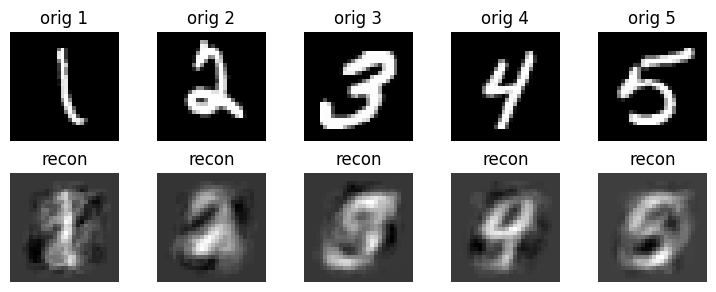

[mlp] Label not-a の例 (mlp)


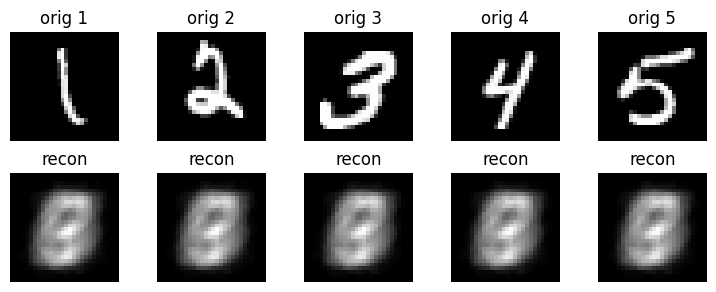

[proc] Label not-a の例 (proc)


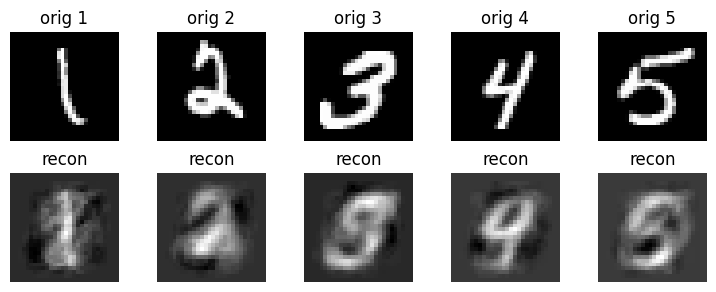

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, spill_num=100, a_label=0
  pseudo-inverse ACC   : all=0.6900, a=0.8571, not-a=0.6774
  MLP recon ACC        : all=0.1400, a=0.0000, not-a=0.1505
      proc recon ACC        : all=0.6800, a=0.8571, not-a=0.6667
  pinv orth recon ACC        : all=0.6700, a=0.8571, not-a=0.6559
  pinv not orth recon ACC        : all=0.6700, a=0.8571, not-a=0.6559
UMAP seed: 0


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label not-a の例 (pinv)


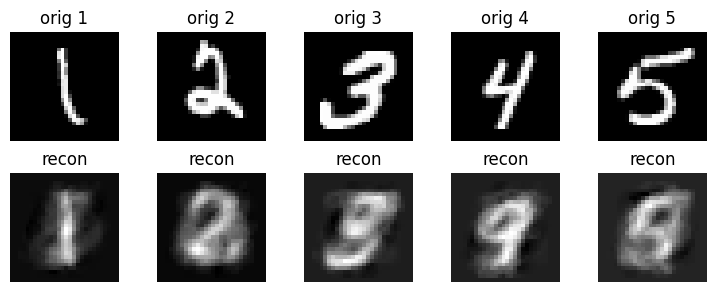

[mlp] Label not-a の例 (mlp)


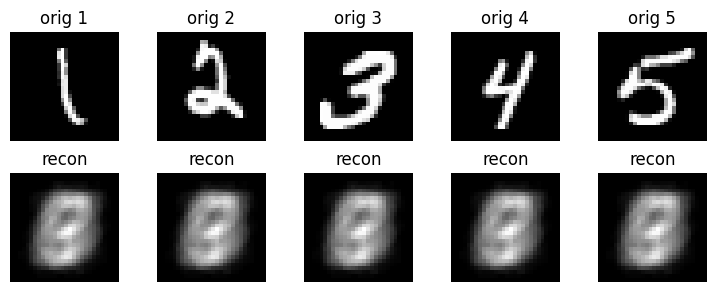

[proc] Label not-a の例 (proc)


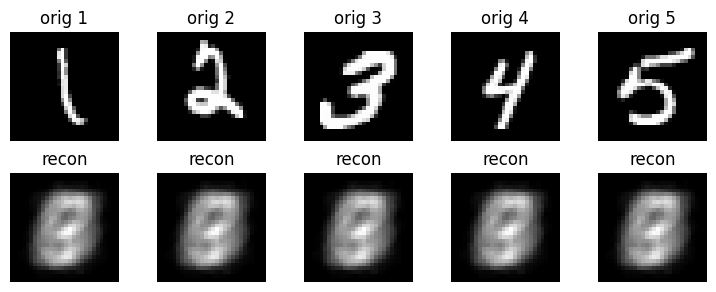

[anchor_local_leak] dataset=mnist, F_type=umap, dim=10, spill_num=100, a_label=0
  pseudo-inverse ACC   : all=0.4800, a=0.8571, not-a=0.4516
  MLP recon ACC        : all=0.1400, a=0.0000, not-a=0.1505
      proc recon ACC        : all=0.1400, a=0.0000, not-a=0.1505
  pinv orth recon ACC        : all=0.1400, a=0.0000, not-a=0.1505
  pinv not orth recon ACC        : all=0.1500, a=0.0000, not-a=0.1613


In [24]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["even"], # "local", "even", 
    "y_name": ["target"],
    "num_institution_user": [200],
    "data_distribution": ["even"],
    "anchor_method": ["smote"], # "smote"
    "num_anchor_data": [100],
    "dim_intermediate": [10],
    "spill_num": [100],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [0],
    "gamma_ratio": [1.0],
    "seed":[i for i in range(1)]
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


## ぶんぷ

In [25]:
def build_pca_forward_inverse(X: np.ndarray, n_components: int):
    """
    X       : (n, d)
    returns : F (d,k), F_pinv (k,d), mean, forward, inverse
    """
    X = np.asarray(X, float)
    mean_X = X.mean(axis=0, keepdims=True)   # (1, d)
    Xc = X - mean_X

    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    F = Vt[:n_components].T                  # (d, k) 列直交
    F_pinv = F.T                             # 疑似逆

    def forward(X_in):
        return (X_in - mean_X) @ F

    def inverse(Z_in):
        return Z_in @ F_pinv + mean_X

    return F, F_pinv, mean_X.ravel(), forward, inverse


In [26]:
def run_distribution_pca_attack(base_config) -> dict:
    # ---- config & RNG ----
    if isinstance(base_config, Config):
        cfg = base_config
    elif isinstance(base_config, dict):
        cfg = Config(**base_config)
    else:
        cfg = Config(**vars(base_config))

    seed = int(cfg.seed)
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    random.seed(seed)

    # ---- 全データ読み込み ----
    df_full = load_data(cfg)

    n_total = len(df_full)
    n_inst = min(n_total, int(cfg.num_institution_user))
    idx_inst = rng.choice(n_total, size=n_inst, replace=False)
    mask_inst = np.zeros(n_total, dtype=bool)
    mask_inst[idx_inst] = True

    df_inst = df_full.iloc[idx_inst].reset_index(drop=True)
    df_pool = df_full.loc[~mask_inst]

    # 公開データ X_pub（機関とは完全非重複）
    n_pub = int(getattr(cfg, "spill_distribute_num", 100))
    df_pub = df_pool.sample(n=min(n_pub, len(df_pool)), random_state=seed).reset_index(drop=True)

    # 機関側データ
    y = df_inst[cfg.y_name].to_numpy()
    X = df_inst.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # 公開データ
    y_pub = df_pub[cfg.y_name].to_numpy()
    X_pub = df_pub.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # ラベル a / not-a
    labels = np.unique(y)
    a_label = labels[0]
    mask_a = (y == a_label)
    mask_not_a = ~mask_a

    k = int(cfg.dim_intermediate)

    # ---- 機関: X_inst から F_true を学習し X' を生成 ----
    _, _, _, pca_fwd_inst, _ = build_pca_forward_inverse(X, k)
    X_tilde = pca_fwd_inst(X)   # これだけが流出

    # ---- 攻撃者: disjoint な X_pub だけで F_hat を学習 ----
    F_hat, F_hat_pinv, mean_pub, _, _ = build_pca_forward_inverse(X_pub, k)

    # ---- 攻撃者: F_hat^T と mean_pub から復元 ----
    # X ≈ X_tilde F_hat^T + mean_pub
    X_rec_dist = X_tilde @ F_hat_pinv + mean_pub

    # ---- 評価・可視化（既存関数を再利用）----
    rmse_dist = compute_rmse_metrics(X, X_rec_dist, mask_a, mask_not_a)
    acc_dist  = compute_acc_metrics(X, y, X_rec_dist, mask_a, mask_not_a, cfg)

    visualize_all_reconstructions(
        X, y, a_label, cfg.dataset,
        recon_dict={"pca_dist": X_rec_dist},
    )

    print(
        f"[dist_pca_attack] dataset={cfg.dataset}, dim={k}, "
        f"n_inst={n_inst}, n_pub={len(df_pub)}, a_label={a_label}"
    )
    print("  dist-PCA ACC       : "
          f"all={acc_dist['all']:.4f}, a={acc_dist['a']:.4f}, not-a={acc_dist['not_a']:.4f}")

    return {
        "a_label": a_label,
        "rmse_dist_all": rmse_dist["all"],
        "rmse_dist_a": rmse_dist["a"],
        "rmse_dist_not_a": rmse_dist["not_a"],
        "acc_dist_all": acc_dist["all"],
        "acc_dist_a": acc_dist["a"],
        "acc_dist_not_a": acc_dist["not_a"],
        "X": X,
        "y": y,
        "X_tilde": X_tilde,
        "X_rec_dist": X_rec_dist,
    }


In [ ]:
base_config = {
    "name": "tutorial_mnist",
    "dataset": "mnist",
    "y_name": "target",
    "num_institution_user": 1000,
    "data_distribution": "even",
    "dim_intermediate": 10,
    "spill_distribute_num": 1000,
    "seed": 81,
}

res = run_distribution_pca_attack(base_config)
res["acc_dist_all"], res["rmse_dist_all"]


# 分布

In [ ]:
def build_distribution_based_inverse(df_public: pd.DataFrame, cfg, rng):
    """
    df_public: num_institution_user に使っていない公開データ（spill_distribute_num 行など）
    から、F(sim) とその逆写像 f_inv を学習して返す。
    """
    y_pub = df_public[cfg.y_name].to_numpy()
    X_pub = df_public.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # 攻撃者側の次元削減 F(sim)
    projector_pub = dimensionality_reduction.build_dimensionality_projector(
        X_pub,
        n_components=int(cfg.dim_intermediate),
        F_type=cfg.F_type,
        seed=int(cfg.seed),
        config=cfg,
        y=y_pub,
    )
    Z_pub = projector_pub(X_pub)  # (n_pub, k)

    # Z_pub -> X_pub の線形逆写像（中心化付き ridge）を学習
    def f_inv(Z_input: np.ndarray) -> np.ndarray:
        X_rec, _ = reconstruct_linear_ridge(
            A_tilde_leak=Z_pub,
            A_leak=X_pub,
            X_tilde=Z_input,
            lam=1e-3,
        )
        return X_rec

    return projector_pub, f_inv


In [ ]:
import numpy as np

def build_pca_forward_inverse(X: np.ndarray, n_components: int):
    """
    X: (n_samples, d)
    n_components: k

    戻り値:
      F        : (d, k)  PCA 射影（列直交）
      F_pinv   : (k, d)  F の疑似逆（= F^T）
      mean_X   : (d,)    平均
      forward  : X -> Z = (X - mean_X) F
      inverse  : Z -> X_hat = Z F^T + mean_X
    """
    X = np.asarray(X, float)
    mean_X = X.mean(axis=0, keepdims=True)  # (1, d)
    Xc = X - mean_X

    # PCA = 中心化 + SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    F = Vt[:n_components].T        # (d, k), 列直交
    F_pinv = F.T                   # (k, d), 疑似逆

    def forward(X_in):
        return (X_in - mean_X) @ F

    def inverse(Z_in):
        return Z_in @ F_pinv + mean_X

    return F, F_pinv, mean_X.ravel(), forward, inverse


In [ ]:
def run_distribution_attack_reconstruction(base_config) -> dict:
    # ---- config 整形 & 乱数 ----
    if isinstance(base_config, Config):
        cfg = base_config
    elif isinstance(base_config, dict):
        cfg = Config(**base_config)
    else:
        cfg = Config(**vars(base_config))

    seed = int(cfg.seed)
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    random.seed(seed)

    # ---- 全データ読み込み ----
    df_full = load_data(cfg)  # preprocess は base_config_dict 側で False 指定済み

    n_total = len(df_full)
    n_use = min(n_total, int(cfg.num_institution_user))

    # 機関が使うデータ（X, y）
    idx_inst = rng.choice(n_total, size=n_use, replace=False)
    mask_inst = np.zeros(n_total, dtype=bool)
    mask_inst[idx_inst] = True
    df_inst = df_full.iloc[idx_inst].reset_index(drop=True)

    y = df_inst[cfg.y_name].to_numpy()
    X = df_inst.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # 攻撃者が分布から入手できるデータ（機関に使われていない部分）
    n_pub = int(getattr(cfg, "spill_distribute_num", 100))
    df_pool = df_full.loc[~mask_inst]
    df_public = df_pool.sample(n=min(n_pub, len(df_pool)), random_state=seed).reset_index(drop=True)

    # ラベル a / not-a
    labels = np.unique(y)
    a_label = labels[0]
    mask_a = (y == a_label)
    mask_not_a = ~mask_a

    # ---- 機関側の次元削減 F_i ----
    projector_inst = dimensionality_reduction.build_dimensionality_projector(
        X,
        n_components=int(cfg.dim_intermediate),
        F_type=cfg.F_type,
        seed=seed,
        config=cfg,
        y=y,
    )
    X_tilde = projector_inst(X)

    # # ---- 攻撃者側: 分布から F(sim) と逆写像を構築 ----
    # projector_pub, f_inv = build_distribution_based_inverse(df_public, cfg, rng)

    # # ---- 分布ベース逆写像で復元 ----
    # X_rec_dist = f_inv(X_tilde)

    # # ---- 評価・可視化（既存関数を再利用）----
    # rmse_dist = compute_rmse_metrics(X, X_rec_dist, mask_a, mask_not_a)
    # acc_dist = compute_acc_metrics(X, y, X_rec_dist, mask_a, mask_not_a, cfg)


    k = int(cfg.dim_intermediate)

    F, F_pinv, mean_X, pca_forward, pca_inverse = build_pca_forward_inverse(X, k)

    Z = pca_forward(X)          # 次元削減後
    X_rec_pca = pca_inverse(Z)  # F† からの再構成

    # 既存の評価関数でそのまま評価
    rmse_pca = compute_rmse_metrics(X, X_rec_pca, mask_a, mask_not_a)
    acc_pca  = compute_acc_metrics(X, y, X_rec_pca, mask_a, mask_not_a, cfg)

    visualize_all_reconstructions(
        X, y, a_label, cfg.dataset,
        recon_dict={"pca": X_rec_pca},
    )

    print(
        f"[distribution_attack] dataset={cfg.dataset}, F_type={cfg.F_type}, "
        f"dim={X_tilde.shape[1]}, n_inst={n_use}, n_public={len(df_public)}, a_label={a_label}"
    )
    print("  dist-based ACC      : "
          f"all={acc_pca['all']:.4f}, a={acc_pca['a']:.4f}, not-a={acc_pca['not_a']:.4f}")

    return {
        "a_label": a_label,
        # "rmse_dist_all": rmse_dist["all"],
        # "rmse_dist_a": rmse_dist["a"],
        # "rmse_dist_not_a": rmse_dist["not_a"],
        # "acc_dist_all": acc_dist["all"],
        # "acc_dist_a": acc_dist["a"],
        # "acc_dist_not_a": acc_dist["not_a"],
        "rmse_pca_all": rmse_pca["all"],
        "rmse_pca_a": rmse_pca["a"],
        "rmse_pca_not_a": rmse_pca["not_a"],
        "acc_pca_all": acc_pca["all"],
        "acc_pca_a": acc_pca["a"],
        "acc_pca_not_a": acc_pca["not_a"],  
        "X": X,
        "y": y,
        "X_tilde": X_tilde,
    }


In [ ]:
def run_distribution_attack_grid(base_config_dict: dict):
    from itertools import product
    keys = list(base_config_dict.keys())
    value_lists = [
        (v if isinstance(v, (list, tuple)) else [v])
        for v in (base_config_dict[k] for k in keys)
    ]

    records = []
    for values in product(*value_lists):
        cfg_kwargs = {k: v for k, v in zip(keys, values)}
        cfg = Config(**cfg_kwargs)
        res = run_distribution_attack_reconstruction(cfg)

        record = dict(cfg_kwargs)
        record["acc_pca_all"] = res["acc_pca_all"]
        record["acc_pca_a"] = res["acc_pca_a"]
        record["acc_pca_not_a"] = res["acc_pca_not_a"]
        records.append(record)

    return pd.DataFrame(records)


[pca] Label not-a の例 (pca)


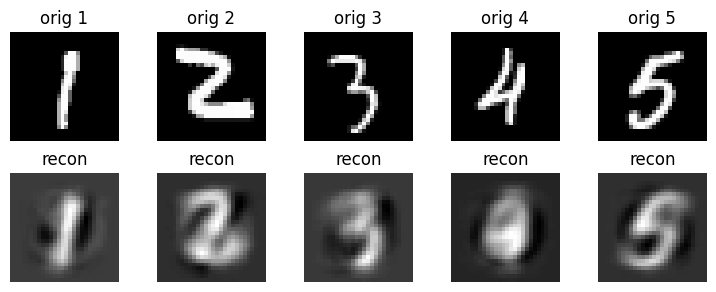

[distribution_attack] dataset=mnist, F_type=svd, dim=10, n_inst=1000, n_public=1000, a_label=0
  dist-based ACC      : all=0.7370, a=0.8349, not-a=0.7250
[pca] Label not-a の例 (pca)


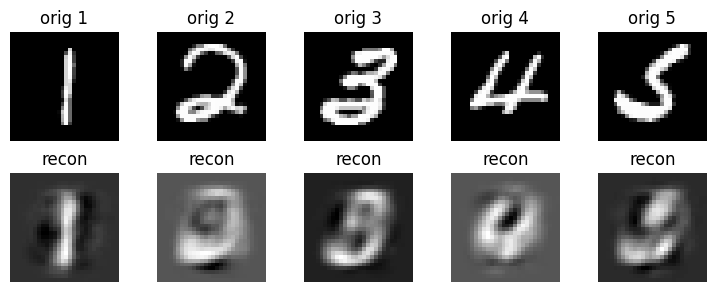

[distribution_attack] dataset=mnist, F_type=svd, dim=10, n_inst=1000, n_public=1000, a_label=0
  dist-based ACC      : all=0.7550, a=0.8866, not-a=0.7409
[pca] Label not-a の例 (pca)


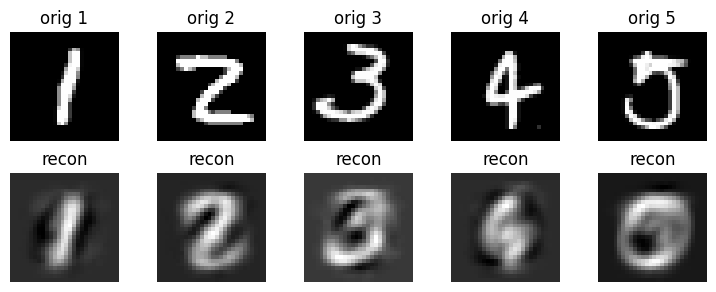

[distribution_attack] dataset=mnist, F_type=svd, dim=10, n_inst=1000, n_public=1000, a_label=0
  dist-based ACC      : all=0.7800, a=0.8605, not-a=0.7724


,name,dataset,spill_type,y_name,num_institution_user,data_distribution,anchor_method,num_anchor_data,dim_intermediate,spill_distribute_num,F_type,inter_normalization,preprocess,smote_ratio,gamma_ratio,seed,acc_pca_all,acc_pca_a,acc_pca_not_a
0,tutorial_mnist,mnist,even,target,1000,even,gaussian,1000,10,1000,svd,False,False,0.8,1.0,81,0.737,0.834862,0.725028
1,tutorial_mnist,mnist,even,target,1000,even,gaussian,1000,10,1000,svd,False,False,0.8,1.0,91,0.755,0.886598,0.740864
2,tutorial_mnist,mnist,even,target,1000,even,gaussian,1000,10,1000,svd,False,False,0.8,1.0,101,0.780,0.860465,0.772429


In [ ]:
base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": ["mnist"],
    "spill_type": ["even"],
    "y_name": ["target"],
    "num_institution_user": [1000],
    "data_distribution": ["even"],
    "anchor_method": ["gaussian"],
    "num_anchor_data": [1000],
    "dim_intermediate": [10],
    "spill_distribute_num": [1000],
    "F_type": ["svd"],
    "inter_normalization": [False],
    "preprocess": [False],
    "smote_ratio": [0.8],
    "gamma_ratio": [1.0],
    "seed": [81, 91, 101],
}

df_results = run_distribution_attack_grid(base_config_dict)
df_results
